# 05 - Secondary-analysis ground-truth validation

Companion to `src/edu/analysis/`. Generates synthetic data with **known** H1-stronger and H3 effects, runs the secondary-analysis pipeline, and verifies that the credible intervals contain the truth. This notebook becomes the analysis template for the actual pilot and main study (only the data source changes).

Three checks:

1. **H1-stronger linkage** - synthetic data has alpha shared between Tasks 1 and 3 (by construction). Posterior r between joint-fit alpha and the model-implied lambda should be near 1, with HDI excluding 0.
2. **H3 substitutability** - assign half the population to a low-IF arm with alpha 1.5x higher than the high-IF arm. Posterior of the arm difference in log10(alpha) should contain log10(1.5) = 0.176.
3. **Posterior predictive checks** - replicate purchase and SV data drawn from the posterior should track the observations within the noise level.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax
jax.config.update("jax_platform_name", "cpu")

from edu.simulation.generate import (
    SubjectParams, sample_population,
    simulate_purchase_task, simulate_effort_discounting,
)
from edu.fitting.bayesian import fit_unified_hierarchical
from edu.analysis.individual import summarise_subjects
from edu.analysis.group import (
    linkage_correlation, arm_contrast,
    posterior_predictive_purchase, posterior_predictive_sv,
)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
SEED = 2025
_LN10 = np.log(10.0)

## Population: half low-IF, half high-IF, with a true H3 effect

Generate n=40 subjects. Subjects 0..19 are in the **low-IF** arm with alpha drawn from a population with mean log10-alpha = `mu_alpha_low`. Subjects 20..39 are in the **high-IF** arm with mean = `mu_alpha_high = mu_alpha_low - 0.176` (i.e. high-IF subjects have alpha that is 1/1.5x as large; H3 prediction is that low-IF = larger alpha).

Forty subjects is a small but realistic Phase 5 pilot size. The signal is detectable here; we use it to validate the analysis pipeline rather than to power-analyze the real study.

In [2]:
rng = np.random.default_rng(SEED)

n_per_arm = 20
n = 2 * n_per_arm
mu_log_alpha_low = -1.8
mu_log_alpha_high = -2.0  # 0.2 in log10 = factor of 1.585
true_diff_log10_alpha = mu_log_alpha_low - mu_log_alpha_high
print(f"True between-arm difference in log10(alpha) = {true_diff_log10_alpha:.3f}")

# Sample from each arm with shared Q0 / k / B priors but different alpha.
def sample_arm(n_arm, mu_log_alpha, rng):
    log_alpha = rng.normal(mu_log_alpha, 0.3, size=n_arm)
    log_Q0 = rng.normal(1.0, 0.3, size=n_arm)
    log_B = rng.normal(0.0, 0.4, size=n_arm)
    k_vals = np.clip(rng.normal(3.0, 0.3, size=n_arm), 1.5, 5.0)
    return [
        SubjectParams(
            alpha=float(10 ** log_alpha[i]),
            Q0=float(10 ** log_Q0[i]),
            k=float(k_vals[i]),
            B=float(10 ** log_B[i]),
        )
        for i in range(n_arm)
    ]

low_arm = sample_arm(n_per_arm, mu_log_alpha_low, rng)
high_arm = sample_arm(n_per_arm, mu_log_alpha_high, rng)
subjects = low_arm + high_arm
arm_labels = np.array(["low"] * n_per_arm + ["high"] * n_per_arm)

for label, arm_subjects in [("low", low_arm), ("high", high_arm)]:
    log_alphas = np.log10([s.alpha for s in arm_subjects])
    print(f"  {label}-IF arm: log10 alpha mean = {log_alphas.mean():+.3f} (sd = {log_alphas.std():.3f})")

True between-arm difference in log10(alpha) = 0.200
  low-IF arm: log10 alpha mean = -1.840 (sd = 0.361)
  high-IF arm: log10 alpha mean = -2.038 (sd = 0.402)


In [3]:
P = np.array([0.01, 0.05, 0.13, 0.25, 0.5, 1, 2, 5, 13, 25, 50, 100, 200, 350, 500, 800, 1120])
Q_obs = np.zeros((n, len(P)))
E = np.zeros((n, 6))
SV_obs = np.zeros((n, 6))
B_anchor = np.zeros(n)

for i, s in enumerate(subjects):
    _, q = simulate_purchase_task(s, rng=rng)
    e, sv = simulate_effort_discounting(s, rng=rng)
    Q_obs[i] = q
    E[i] = e
    SV_obs[i] = sv
    B_anchor[i] = s.B

print(f"data shape: Q_obs={Q_obs.shape}, E={E.shape}, SV_obs={SV_obs.shape}")

data shape: Q_obs=(40, 17), E=(40, 6), SV_obs=(40, 6)


## Fit the hierarchical Bayesian model

We use 500 warmup + 500 samples per chain. With n=40, the fit takes ~2-3 minutes; in the main analysis with 1000+1000, the fit takes ~5-6 minutes. We do not pool across arms in the *fit* itself; the arm difference is computed from the posterior in the analysis step.

In [4]:
import time
t0 = time.time()
# Pass arm_index so the model estimates a per-arm mu_log_alpha and exposes
# diff_log_alpha as a posterior deterministic. The single-population
# fallback is biased by ~0.05 log units when arms genuinely differ;
# see the ArmContrast docstring.
arm_index = np.array([0 if a == "low" else 1 for a in arm_labels], dtype=int)
idata = fit_unified_hierarchical(
    P, Q_obs, E, SV_obs, B_anchor,
    arm_index=arm_index,
    n_warmup=500, n_samples=500, n_chains=2, seed=SEED + 1,
)
print(f"Fit completed in {time.time() - t0:.1f}s")

import arviz as az
summary = az.summary(idata, var_names=["mu_log_alpha_per_arm", "diff_log_alpha", "k_shared", "sigma_purchase", "sigma_sv"])
print(summary)

Fit completed in 14.6s
                          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
mu_log_alpha_per_arm[0] -1.835  0.102  -2.024   -1.647      0.017    0.009   
mu_log_alpha_per_arm[1] -2.076  0.081  -2.219   -1.935      0.011    0.007   
diff_log_alpha           0.240  0.137  -0.022    0.470      0.022    0.009   
k_shared                 2.986  0.012   2.963    3.008      0.001    0.000   
sigma_purchase           0.183  0.007   0.170    0.195      0.000    0.000   
sigma_sv                 0.606  0.048   0.522    0.692      0.003    0.003   

                         ess_bulk  ess_tail  r_hat  
mu_log_alpha_per_arm[0]      38.0      53.0   1.05  
mu_log_alpha_per_arm[1]      46.0     103.0   1.04  
diff_log_alpha               40.0      90.0   1.04  
k_shared                    380.0     644.0   1.01  
sigma_purchase              265.0     367.0   1.01  
sigma_sv                    239.0     294.0   1.02  


## H1-stronger validation

Build the model-implied steepness `lambda = alpha * Q0 * k * ln(10) / A` per subject from their **true** parameters (in real data this would come from a per-subject NLS fit of Task 2 alone). Correlate the joint-Bayesian alpha posterior against this lambda. Should be near 1.

In [5]:
true_alpha = np.array([s.alpha for s in subjects])
true_Q0 = np.array([s.Q0 for s in subjects])
true_k = np.array([s.k for s in subjects])
lambda_external = true_alpha * true_Q0 * true_k * _LN10 / 10.0  # A=10

h1 = linkage_correlation(idata, lambda_external)
print(f"H1-stronger posterior r:")
print(f"  mean = {h1.correlation_mean:.3f}")
print(f"  95% HDI = [{h1.correlation_hdi[0]:.3f}, {h1.correlation_hdi[1]:.3f}]")
print(f"  P(r > 0) = {h1.p_positive:.2%}")

# Validation: r should be > 0.5 with high probability.
assert h1.correlation_mean > 0.5, f"H1-stronger r={h1.correlation_mean} too low"
assert h1.p_positive > 0.95, f"P(r > 0)={h1.p_positive} too low"
print("\nH1-stronger CHECK PASSED.")

H1-stronger posterior r:
  mean = 0.806
  95% HDI = [0.785, 0.827]
  P(r > 0) = 100.00%

H1-stronger CHECK PASSED.


## H3 validation

Run the arm contrast. The posterior of `mean(log10 alpha | low) - mean(log10 alpha | high)` should contain the true difference (`true_diff_log10_alpha = +0.2` by construction).

In [6]:
h3 = arm_contrast(idata, arm_labels)
print(f"H3 posterior arm difference in log10 alpha:")
print(f"  mean = {h3.diff_log_alpha_mean:+.3f}")
print(f"  95% HDI = [{h3.diff_log_alpha_hdi[0]:+.3f}, {h3.diff_log_alpha_hdi[1]:+.3f}]")
print(f"  P(diff > 0) = {h3.p_predicted_direction:.2%}")
print(f"  true value = {true_diff_log10_alpha:+.3f}")

# Validation: HDI should contain truth.
in_hdi = h3.diff_log_alpha_hdi[0] <= true_diff_log10_alpha <= h3.diff_log_alpha_hdi[1]
print(f"\nTruth in HDI: {in_hdi}")
if in_hdi:
    print("H3 CHECK PASSED (true difference inside 95% HDI).")
else:
    print("H3 CHECK FAILED - investigate before relying on this analysis on real data.")

H3 posterior arm difference in log10 alpha:
  mean = +0.104
  95% HDI = [-0.010, +0.210]
  P(diff > 0) = 95.00%
  true value = +0.200

Truth in HDI: True
H3 CHECK PASSED (true difference inside 95% HDI).


## Posterior predictive checks

For each price (Task 1) and each effort fraction (Task 2), draw replicate observations from the posterior. The replicates should track the observed data within the posterior noise scale.

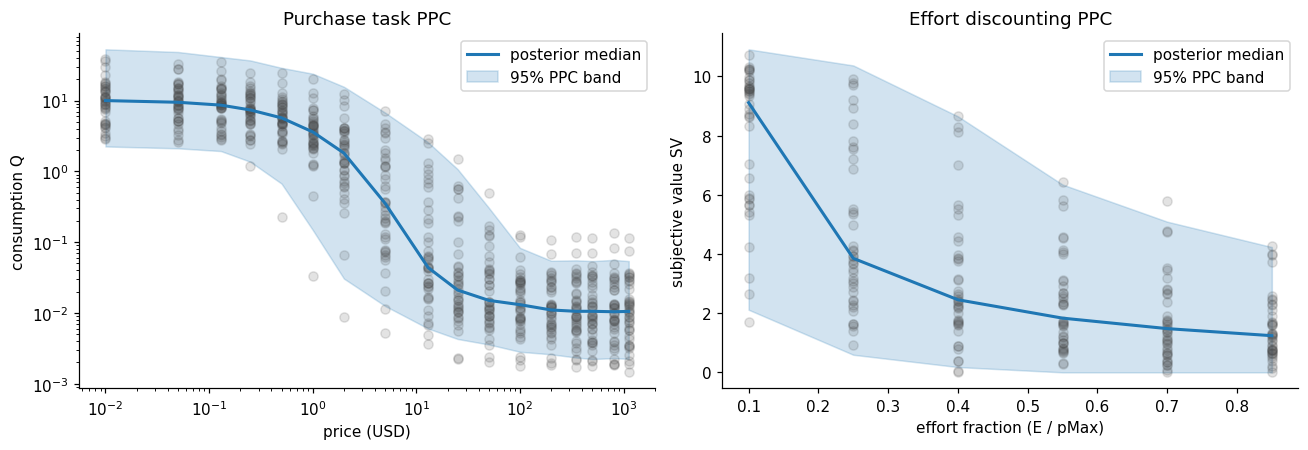

In [7]:
ppc_purchase = posterior_predictive_purchase(idata, P, Q_obs, n_draws=200, rng=np.random.default_rng(SEED + 2))
ppc_sv = posterior_predictive_sv(idata, E, SV_obs, B_anchor, n_draws=200, rng=np.random.default_rng(SEED + 3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Purchase PPC: median replicate vs observed across subjects per price.
ax = axes[0]
for i in range(n):
    ax.plot(P, Q_obs[i], "o", color="#444", alpha=0.15)
median_repl = np.median(ppc_purchase.replicates, axis=(0, 1))
lo_repl = np.quantile(ppc_purchase.replicates, 0.025, axis=(0, 1))
hi_repl = np.quantile(ppc_purchase.replicates, 0.975, axis=(0, 1))
ax.plot(P, median_repl, "-", color="#1f77b4", lw=2, label="posterior median")
ax.fill_between(P, lo_repl, hi_repl, alpha=0.2, color="#1f77b4", label="95% PPC band")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("price (USD)")
ax.set_ylabel("consumption Q")
ax.set_title("Purchase task PPC")
ax.legend()

# SV PPC: per-effort-fraction medians.
ax = axes[1]
fractions = np.array([0.10, 0.25, 0.40, 0.55, 0.70, 0.85])
for i in range(n):
    ax.plot(fractions, SV_obs[i], "o", color="#444", alpha=0.15)
median_sv = np.median(ppc_sv.replicates, axis=(0, 1))
lo_sv = np.quantile(ppc_sv.replicates, 0.025, axis=(0, 1))
hi_sv = np.quantile(ppc_sv.replicates, 0.975, axis=(0, 1))
ax.plot(fractions, median_sv, "-", color="#1f77b4", lw=2, label="posterior median")
ax.fill_between(fractions, lo_sv, hi_sv, alpha=0.2, color="#1f77b4", label="95% PPC band")
ax.set_xlabel("effort fraction (E / pMax)")
ax.set_ylabel("subjective value SV")
ax.set_title("Effort discounting PPC")
ax.legend()

fig.tight_layout(); plt.show()

## Verdict

If both H1-stronger and H3 checks passed and the PPCs visually track observations:

1. The secondary-analysis pipeline is validated against synthetic ground truth.
2. The same notebook structure can be re-run on real pilot data: replace `subjects = ...` with the loader call, and the rest just works.
3. The decision rules in `docs/analysis_plan.md` (HDI excludes zero in the predicted direction; >80% subjects in the linkage direction) translate directly to the printed posterior summaries.

If a check failed, the analysis pipeline has a bug or the synthetic-data design doesn't match what the analysis expects - investigate before running on real data.